# max stocks: 15
# Price Bracket: 90- 600
# max year: 1
# DATA_DIR = 'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
# Seed : 5

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading
all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(5) 
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 15: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        
        df = df.sort_values('Date').reset_index(drop=True)
        if len(df) < 300: # Need enough history for 55-day WMA + 250 day view
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded {len(data['Symbol'].unique())} stocks for behavior analysis.")


Loaded 15 stocks for behavior analysis.


In [3]:
# 3. Strategy Backtest: The WMA Pullback Bounce
def calc_wma(s, period):
    weights = np.arange(1, period + 1)
    return s.rolling(period).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)

trades = []
enriched_data = []

symbols = data['Symbol'].unique()

for symbol in symbols:
    df = data[data['Symbol'] == symbol].copy()
    
    # Calculate WMAs on Full History to avoid starting NaN issues
    df['WMA_5'] = calc_wma(df['Close'], 5)
    df['WMA_21'] = calc_wma(df['Close'], 21)
    df['WMA_55'] = calc_wma(df['Close'], 55)
    
    # NEW: Mature Trend (21 WMA > 55 WMA for 15 straight days)
    df['Trend_Mature'] = (df['WMA_21'] > df['WMA_55']).rolling(15).sum() == 15
    
    # NEW: Upward Velocity (55 WMA is at least 1% higher than 10 days ago)
    df['Velocity_Up'] = df['WMA_55'] > (df['WMA_55'].shift(10) * 1.01)
    
    # Filter to last 250 days for backtest and plotting
    if len(df) > 250:
        df = df.tail(250).reset_index(drop=True)
    
    # The Macro Trend Filter
    df['Trend_Up'] = df['Trend_Mature'] & df['Velocity_Up']
    
    # The Setup (Pullback) - 5 WMA dips below 21 WMA, but Close remains ABOVE 55 WMA (Unbroken Trampoline)
    df['Setup'] = (df['WMA_5'] < df['WMA_21']) & (df['Close'] > df['WMA_55'])
    
    # The Entry Trigger
    df['Cross_Up'] = (df['Close'] > df['WMA_5']) & (df['Close'].shift(1) <= df['WMA_5'].shift(1))
    df['Buy_Signal'] = df['Trend_Up'] & df['Setup'] & df['Cross_Up']
    
    in_trade = False
    entry_price = 0
    entry_date = None
    
    for i, row in df.iterrows():
        if not in_trade and row['Buy_Signal']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
        
        elif in_trade:
            current_price = row['Close']
            current_date = row['Date']
            profit_pct = (current_price - entry_price) / entry_price
            days_held = (current_date - entry_date).days
            
            # Exit Conditions: +5% TP, -3% SL
            if profit_pct >= 0.05 or profit_pct <= -0.03:
                in_trade = False
                trades.append({
                    'Symbol': symbol,
                    'Entry_Date': entry_date,
                    'Exit_Date': current_date,
                    'Entry_Price': entry_price,
                    'Exit_Price': current_price,
                    'Profit_Pct': profit_pct * 100,
                    'Days_Held': days_held,
                    'Exit_Reason': 'Take Profit (+5%)' if profit_pct > 0 else 'Stop Loss (-3%)'
                })
                
    enriched_data.append(df)

data = pd.concat(enriched_data, ignore_index=True)
trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    total_trades = len(trades_df)
    winners = trades_df[trades_df['Profit_Pct'] > 0]
    losers = trades_df[trades_df['Profit_Pct'] <= 0]
    
    win_rate = len(winners) / total_trades * 100
    avg_win = winners['Profit_Pct'].mean() if len(winners) > 0 else 0
    avg_loss = losers['Profit_Pct'].mean() if len(losers) > 0 else 0
    
    exit_reasons = trades_df['Exit_Reason'].value_counts(normalize=True) * 100
    
    summary_html = f'''
    <h3>Strategy Summary</h3>
    <ul>
        <li><b>Total Trades:</b> {total_trades}</li>
        <li><b>Win Rate:</b> {win_rate:.2f}%</li>
        <li><b>Average Win:</b> +{avg_win:.2f}%</li>
        <li><b>Average Loss:</b> {avg_loss:.2f}%</li>
    </ul>
    <h4>Exit Reasons</h4>
    <ul>
    '''
    for reason, pct in exit_reasons.items():
        summary_html += f"<li>{reason}: {pct:.1f}%</li>"
    summary_html += "</ul>"
    
    display(HTML(summary_html))
    
    display(HTML("<h3>Trade Ledger</h3>"))
    display(trades_df)
else:
    print("No trades triggered for these stocks in this 1-year window.")


,Symbol,Entry_Date,Exit_Date,Entry_Price,Exit_Price,Profit_Pct,Days_Held,Exit_Reason
0,SYNGENE,2026-05-26,2026-05-29,465.250000,442.000000,-4.997313,3,Stop Loss (-3%)
1,SYNGENE,2026-06-08,2026-06-23,449.500000,436.000000,-3.003337,15,Stop Loss (-3%)
2,NBCC,2025-11-11,2025-11-13,113.589996,108.980003,-4.058450,2,Stop Loss (-3%)
3,NBCC,2025-11-14,2025-12-08,114.139999,107.980003,-5.396878,24,Stop Loss (-3%)
4,NBCC,2026-05-21,2026-05-27,93.070000,99.099998,6.478993,6,Take Profit (+5%)
5,NAZARA,2025-08-04,2025-08-20,340.500000,304.850006,-10.469895,16,Stop Loss (-3%)
6,NAZARA,2026-02-09,2026-03-02,272.450012,257.500000,-5.487250,21,Stop Loss (-3%)
7,NAZARA,2026-06-09,2026-06-16,278.549988,301.149994,8.113447,7,Take Profit (+5%)
8,KIRIINDUS,2025-10-16,2025-10-30,579.599976,550.099976,-5.089717,14,Stop Loss (-3%)
9,VBL,2025-08-19,2025-08-29,505.399994,487.149994,-3.611001,10,Stop Loss (-3%)


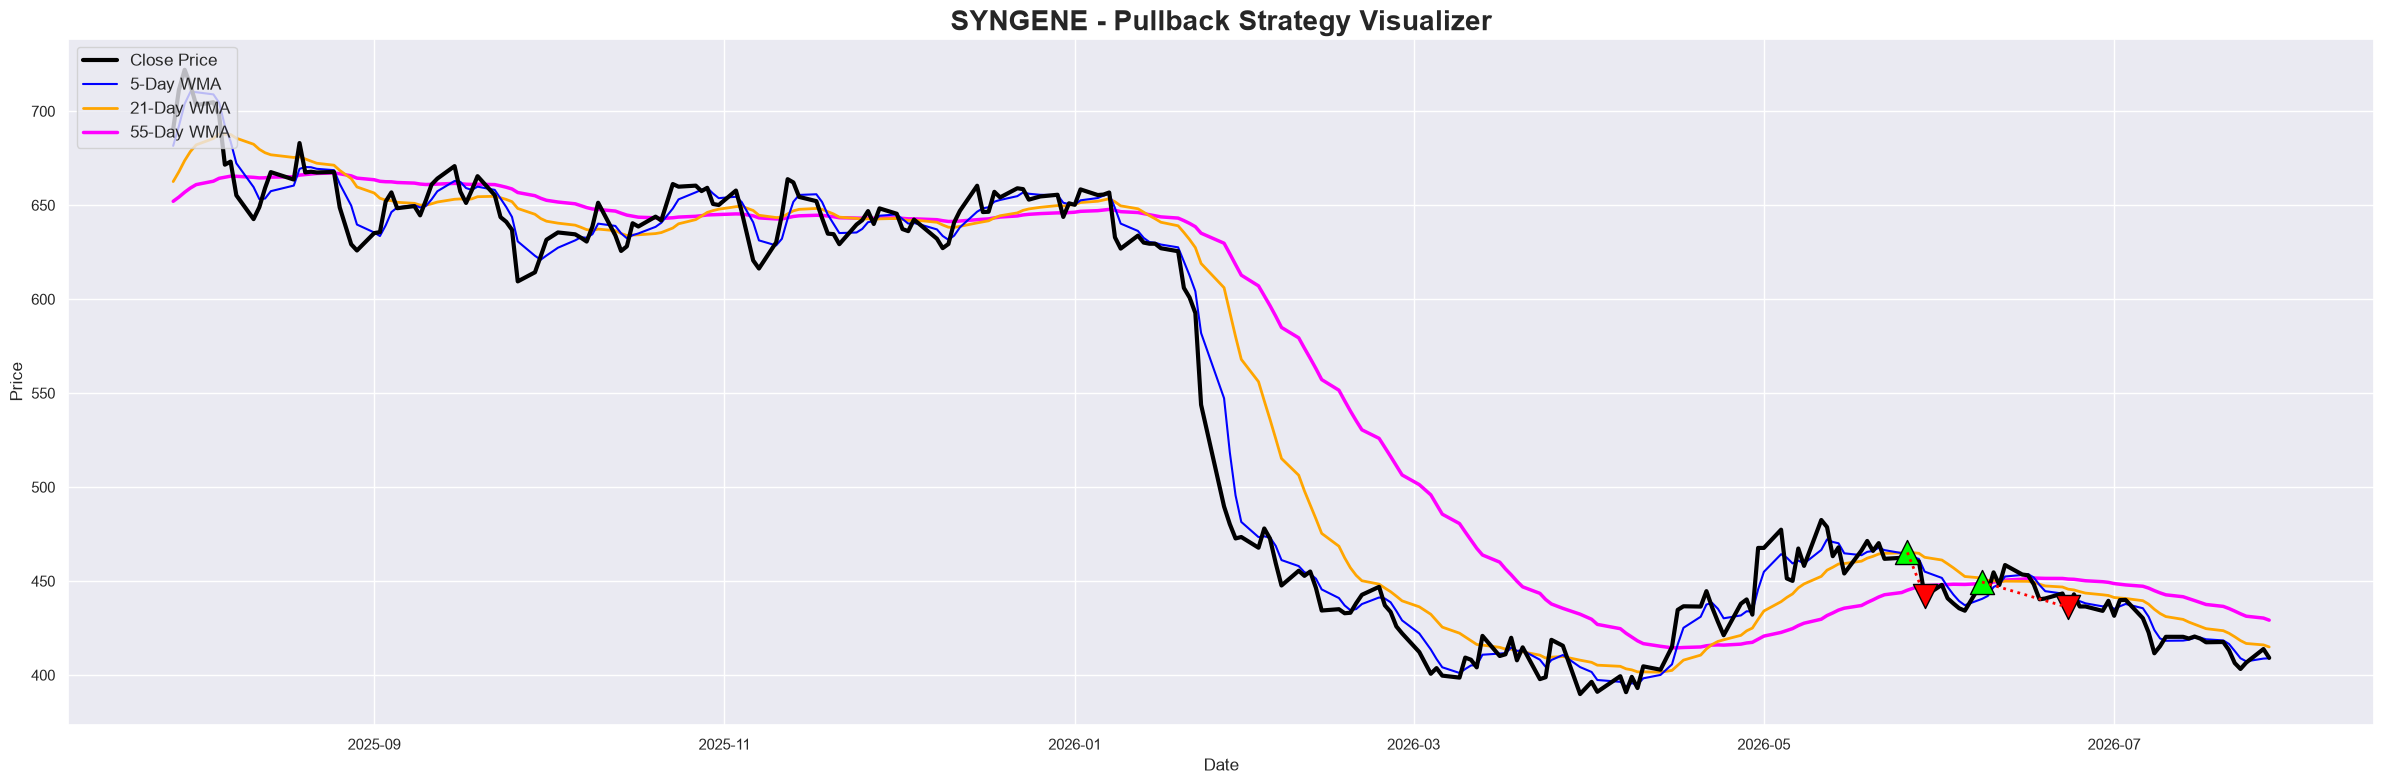

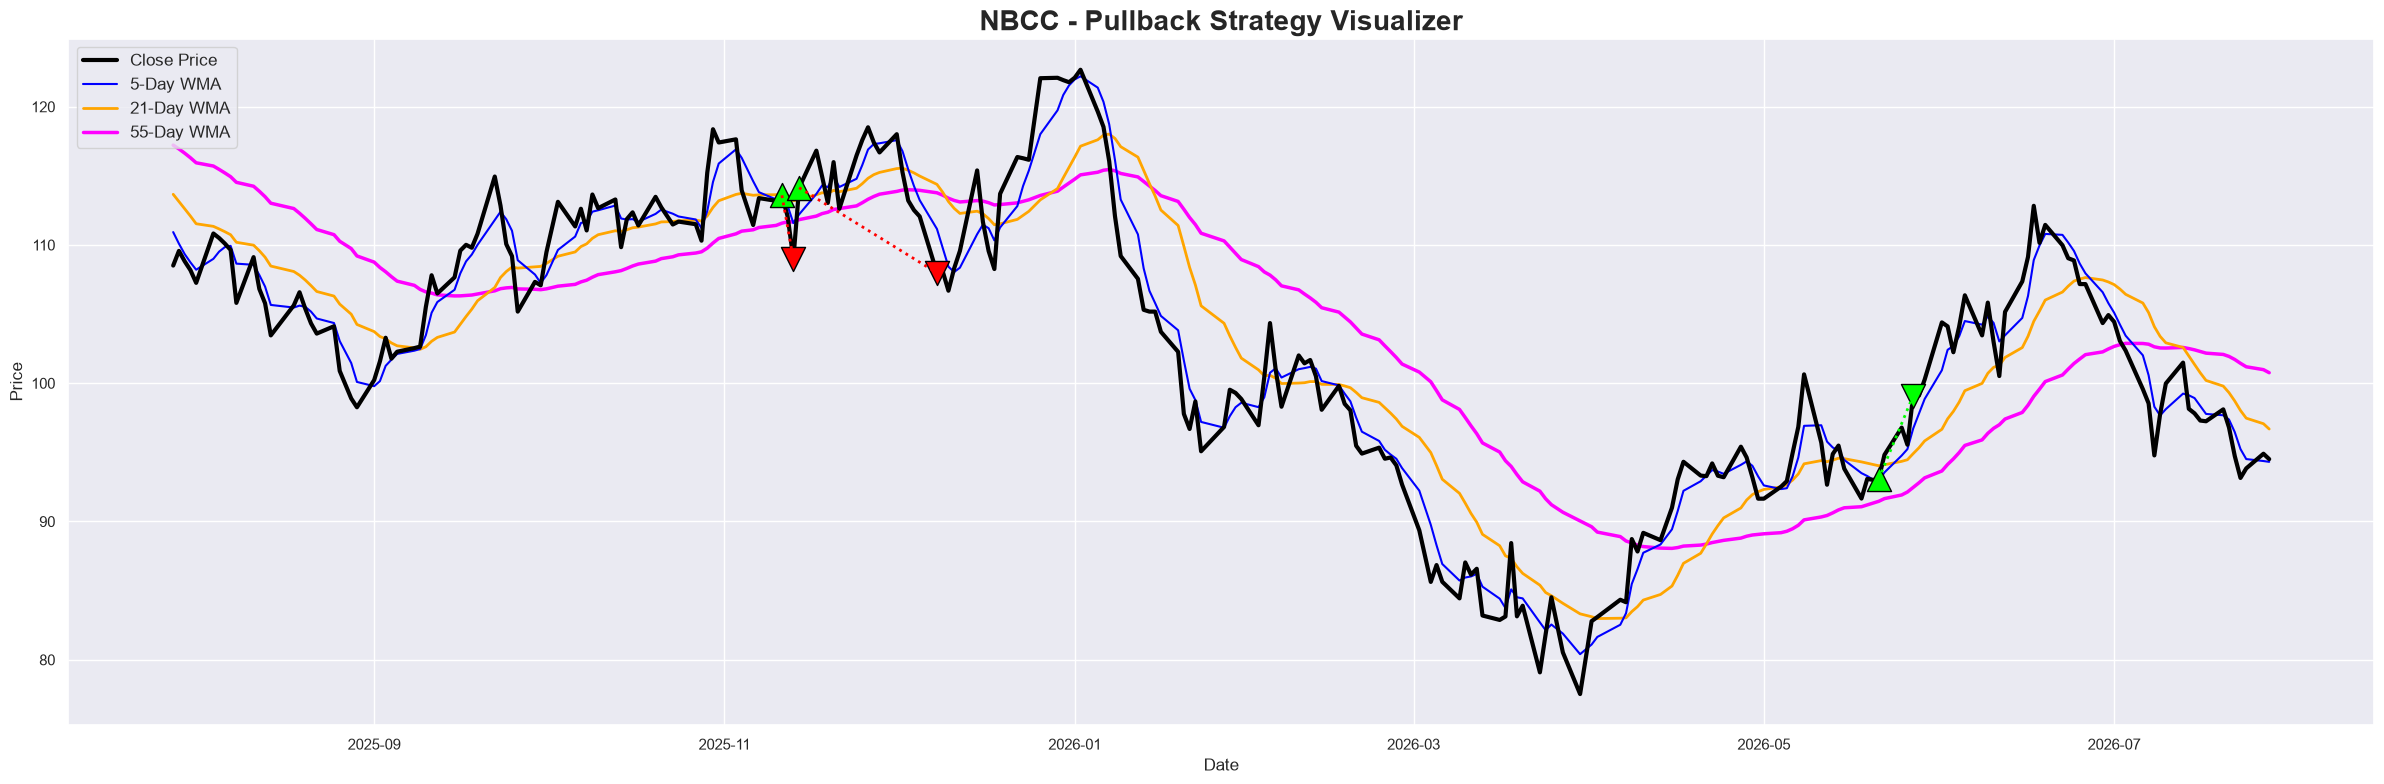

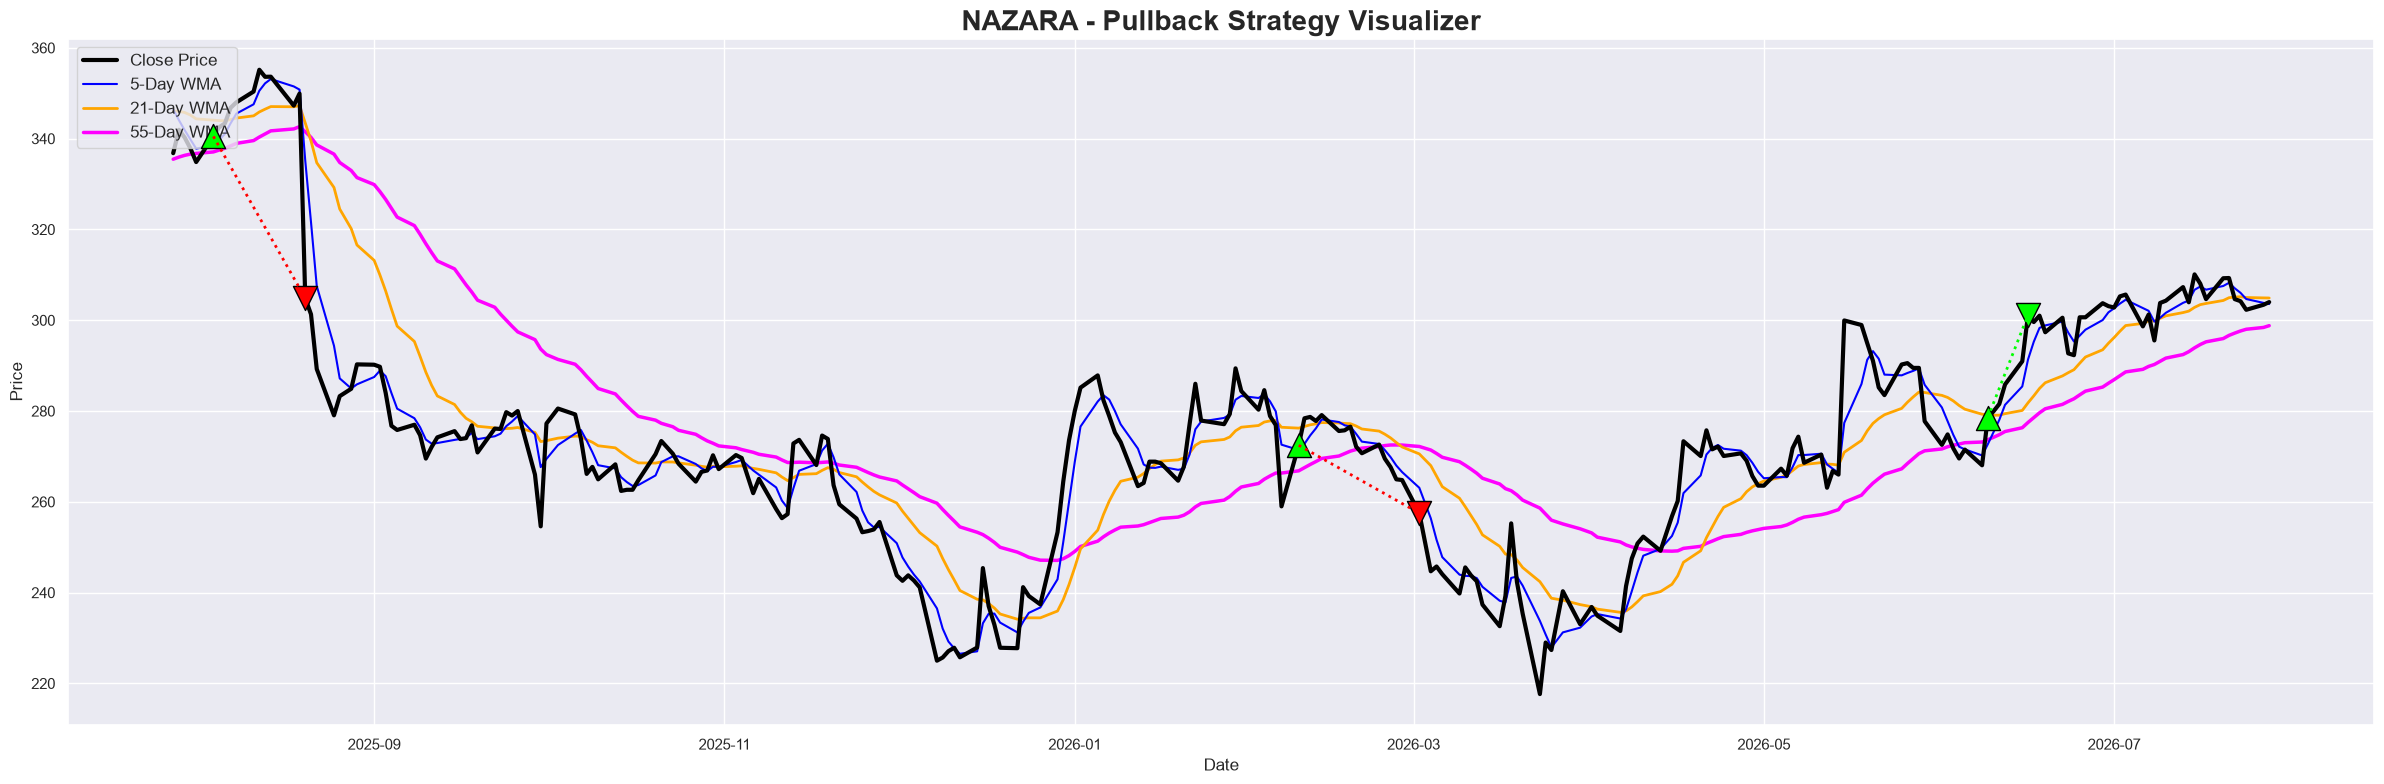

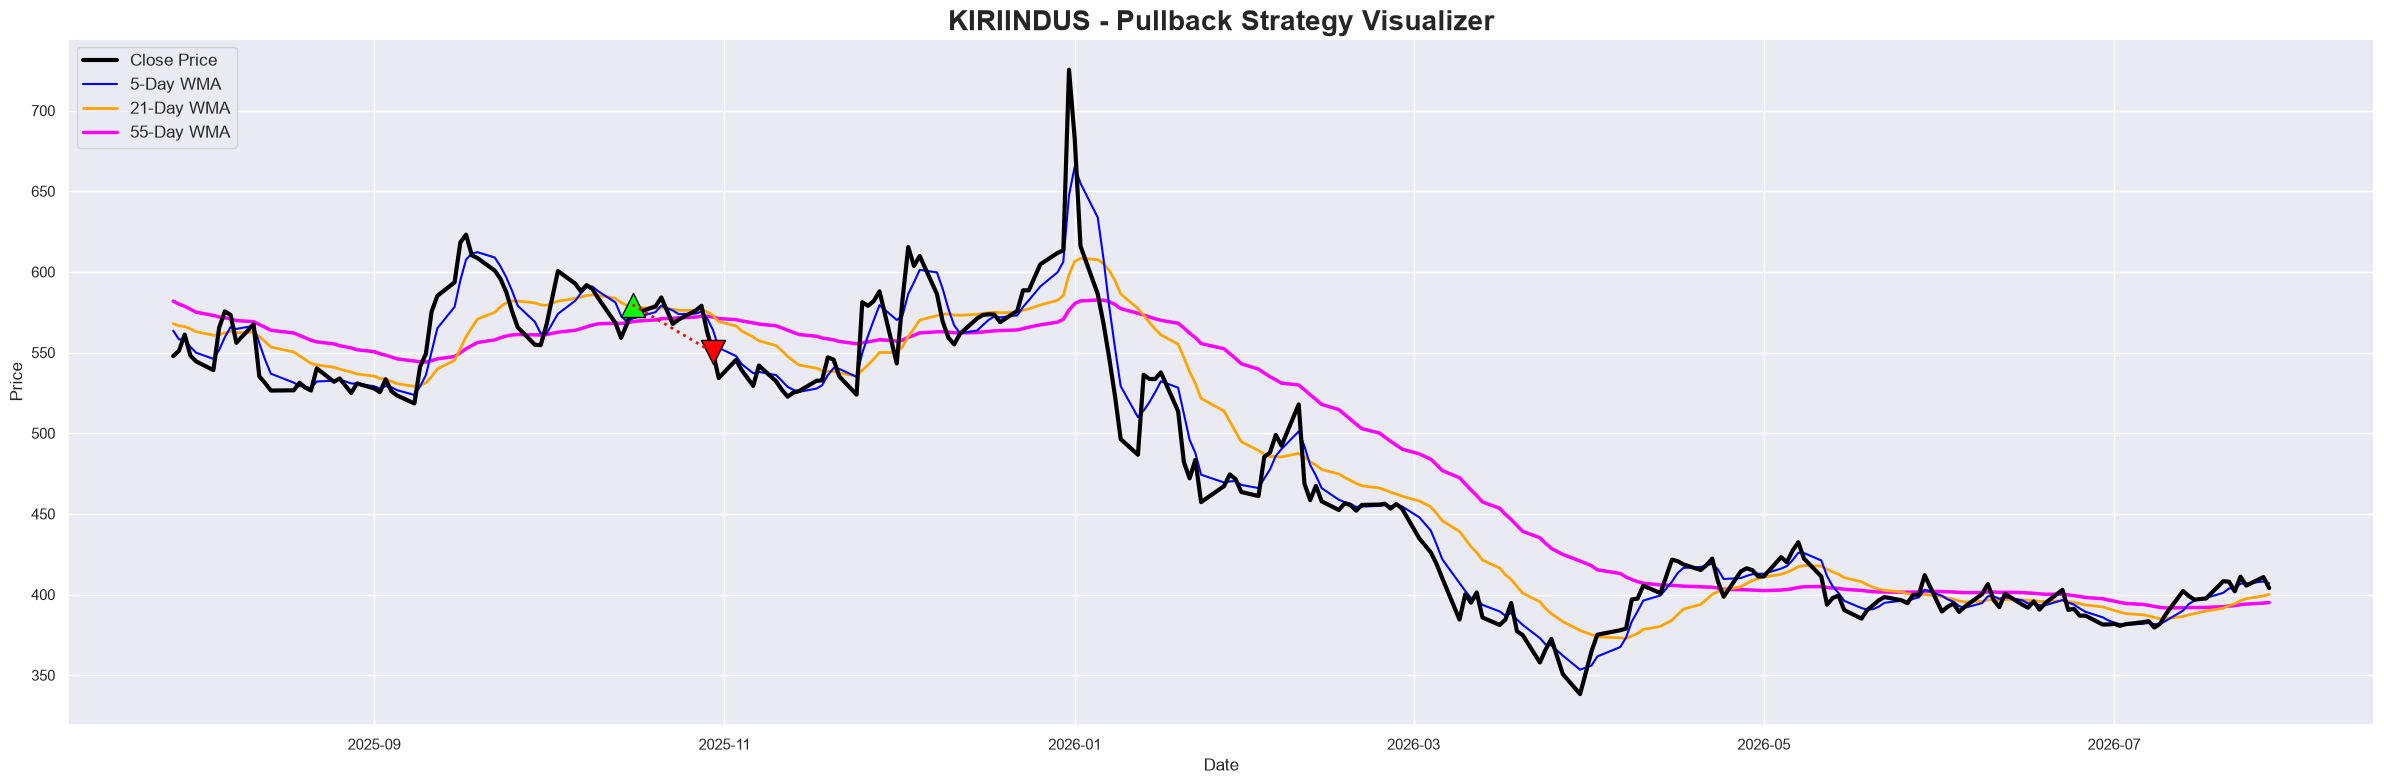

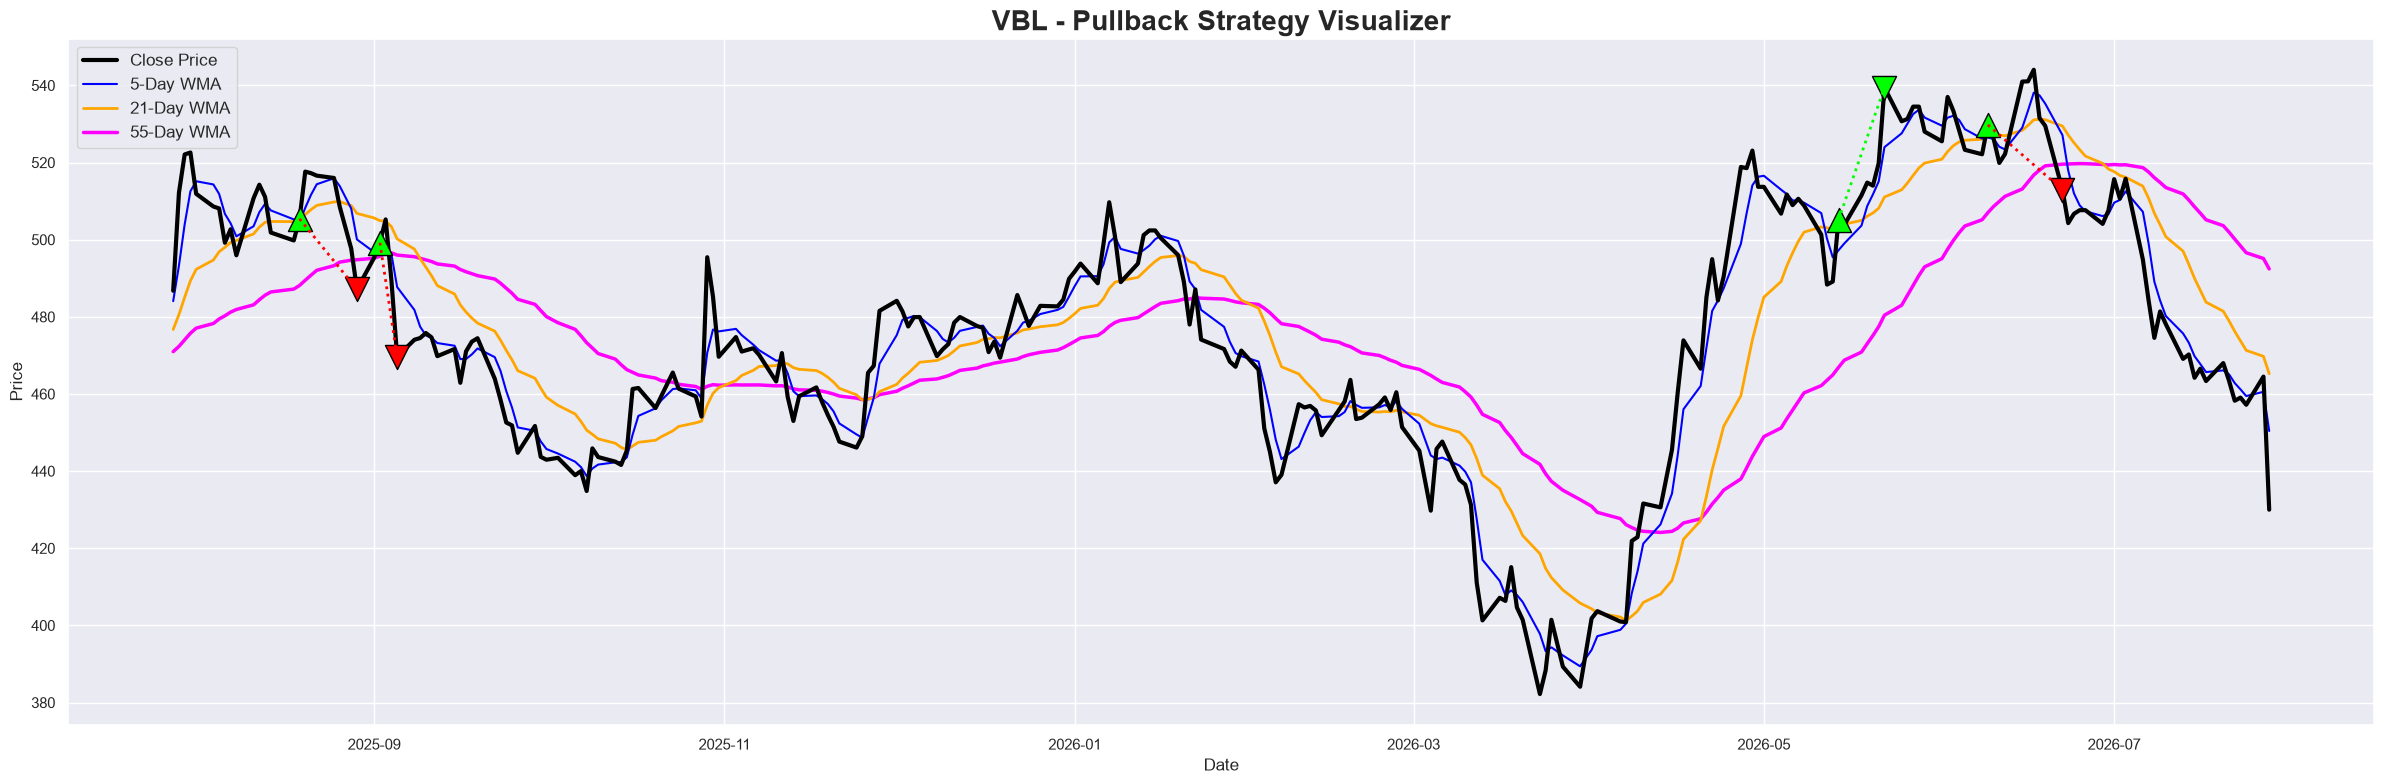

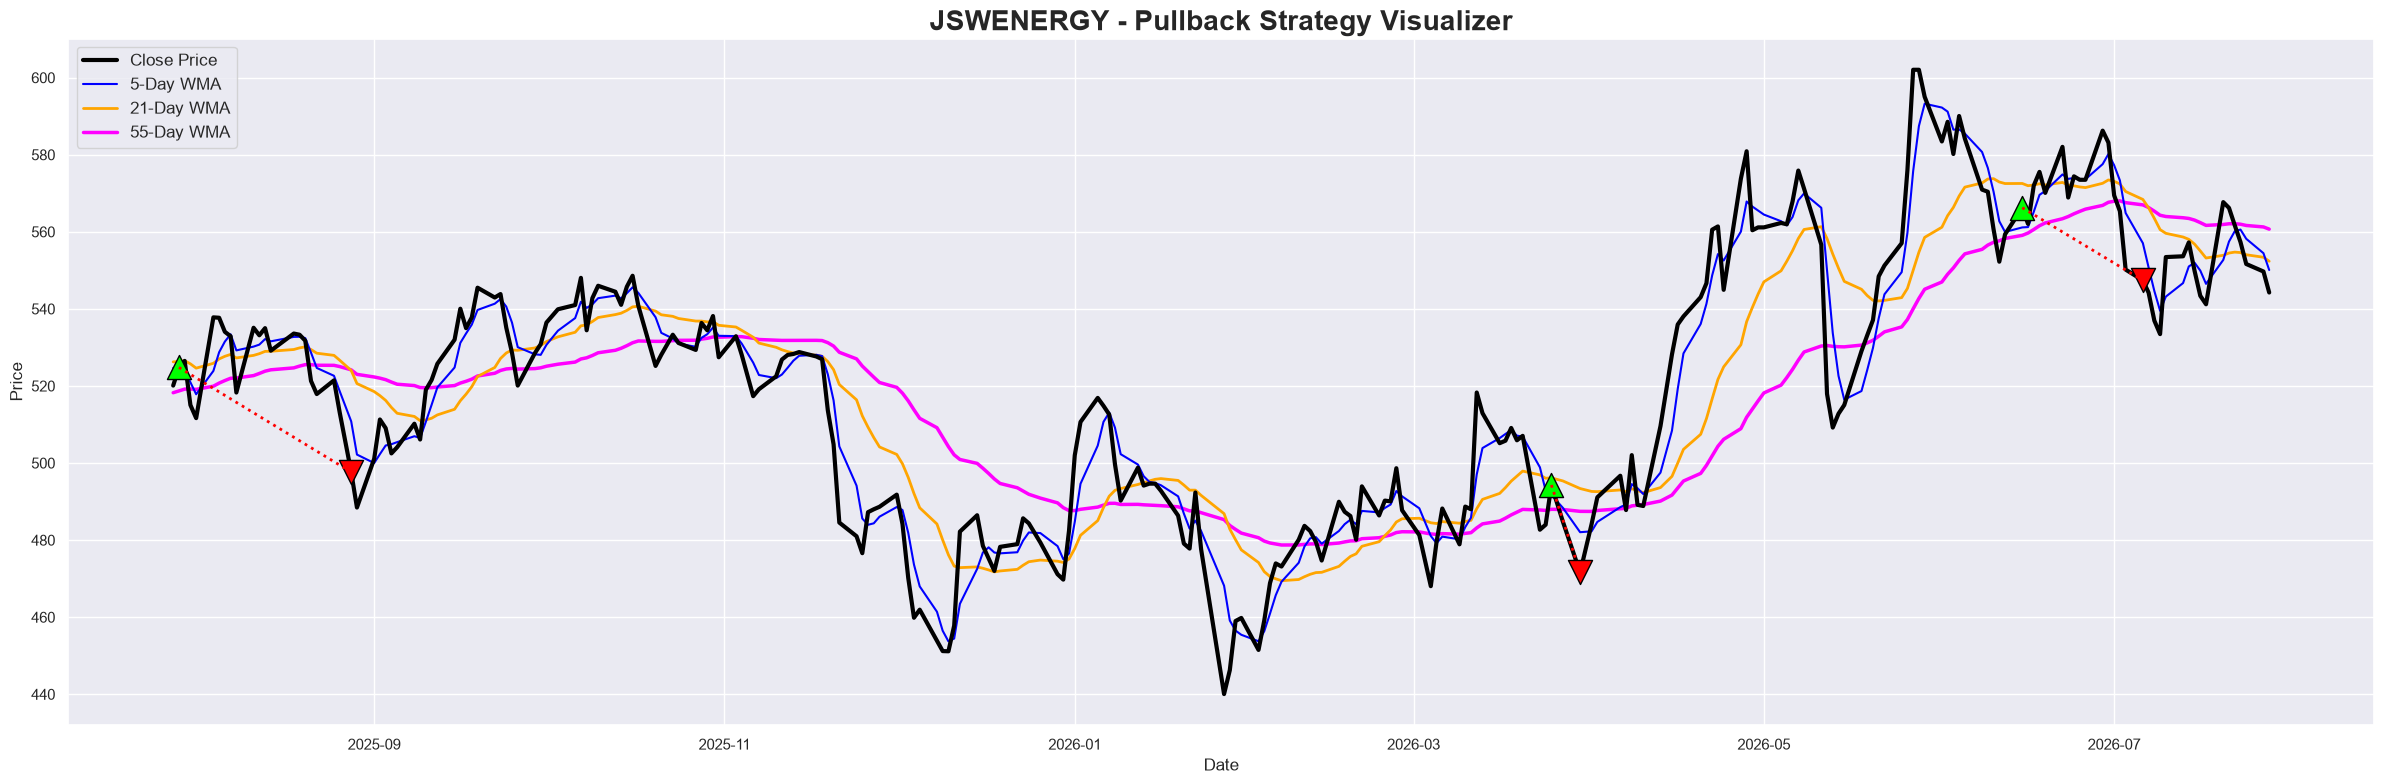

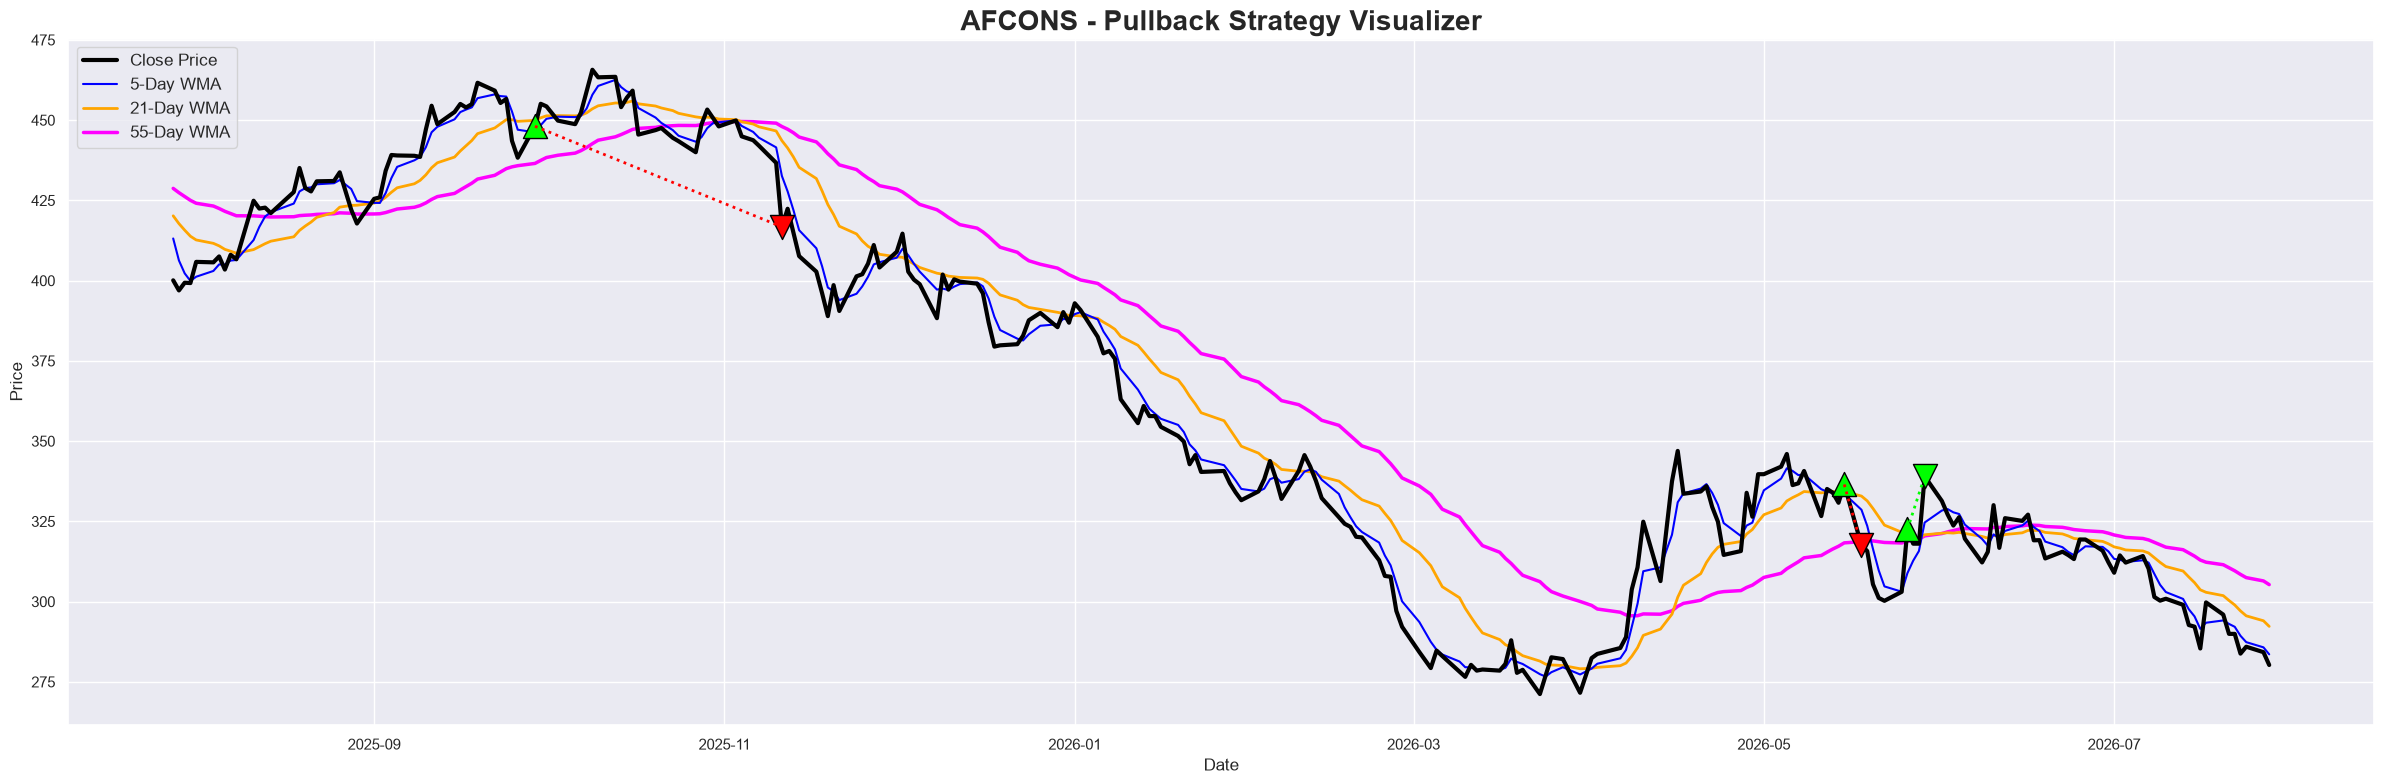

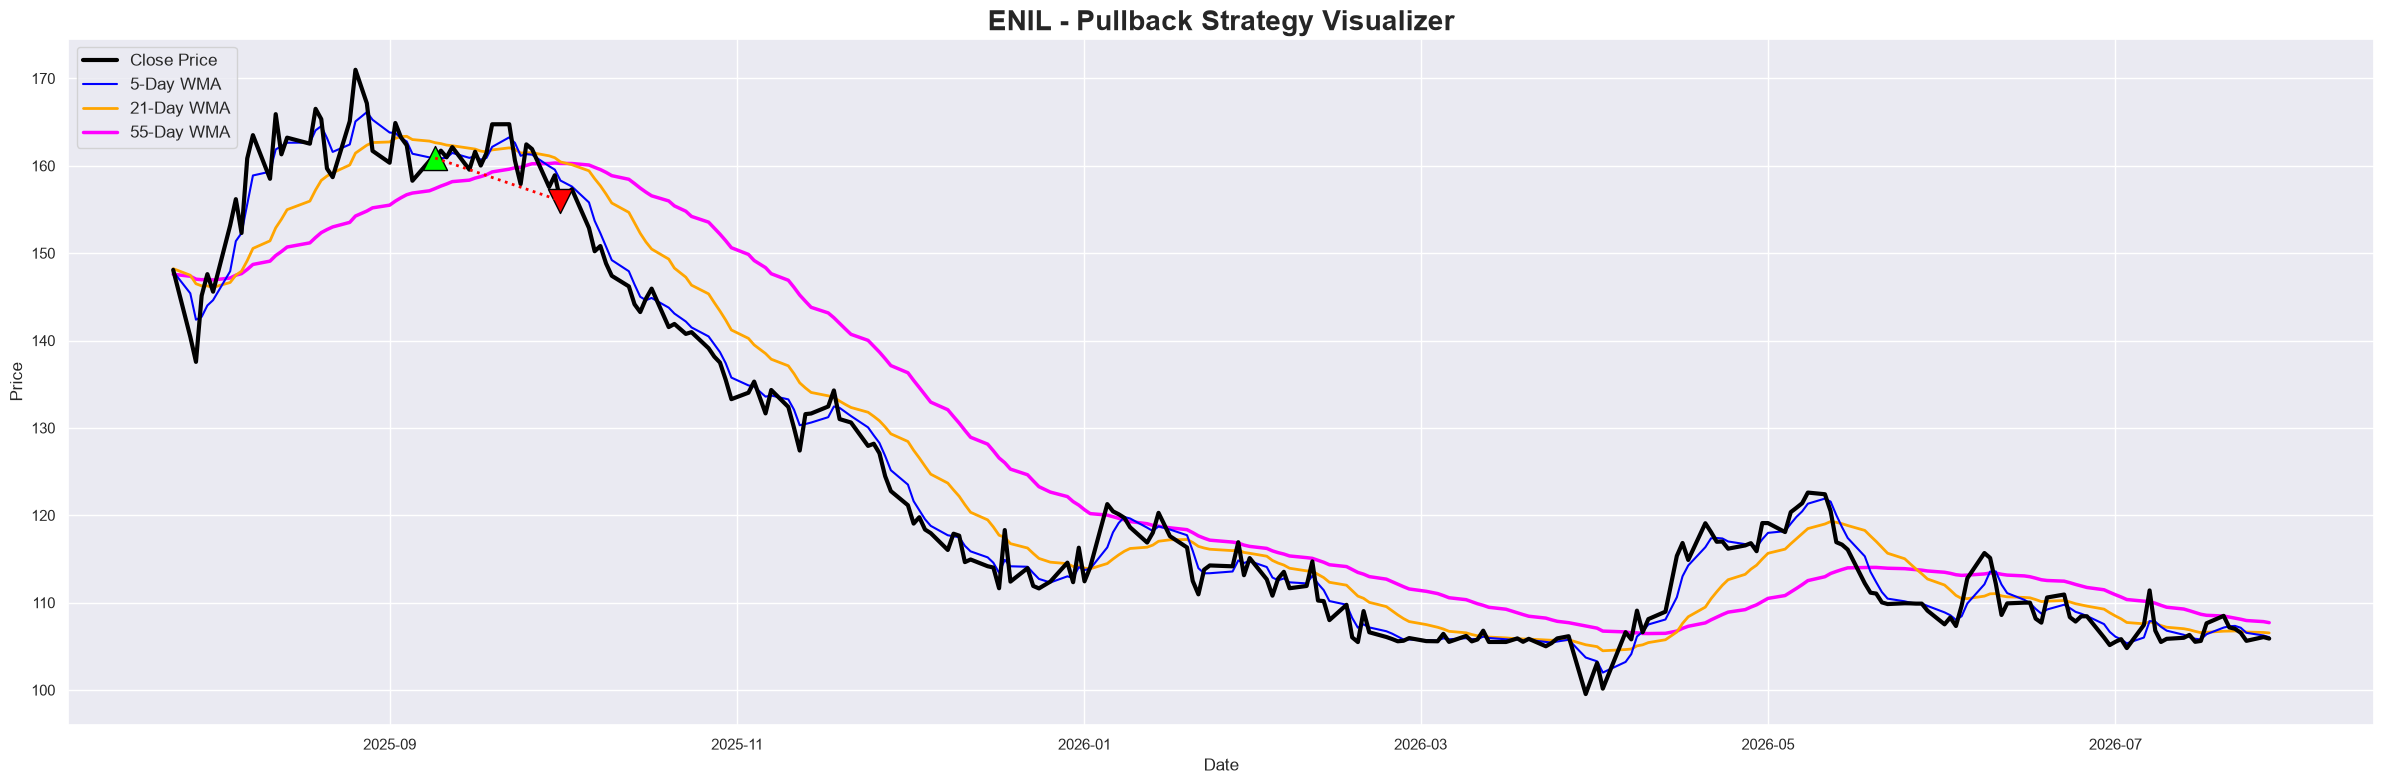

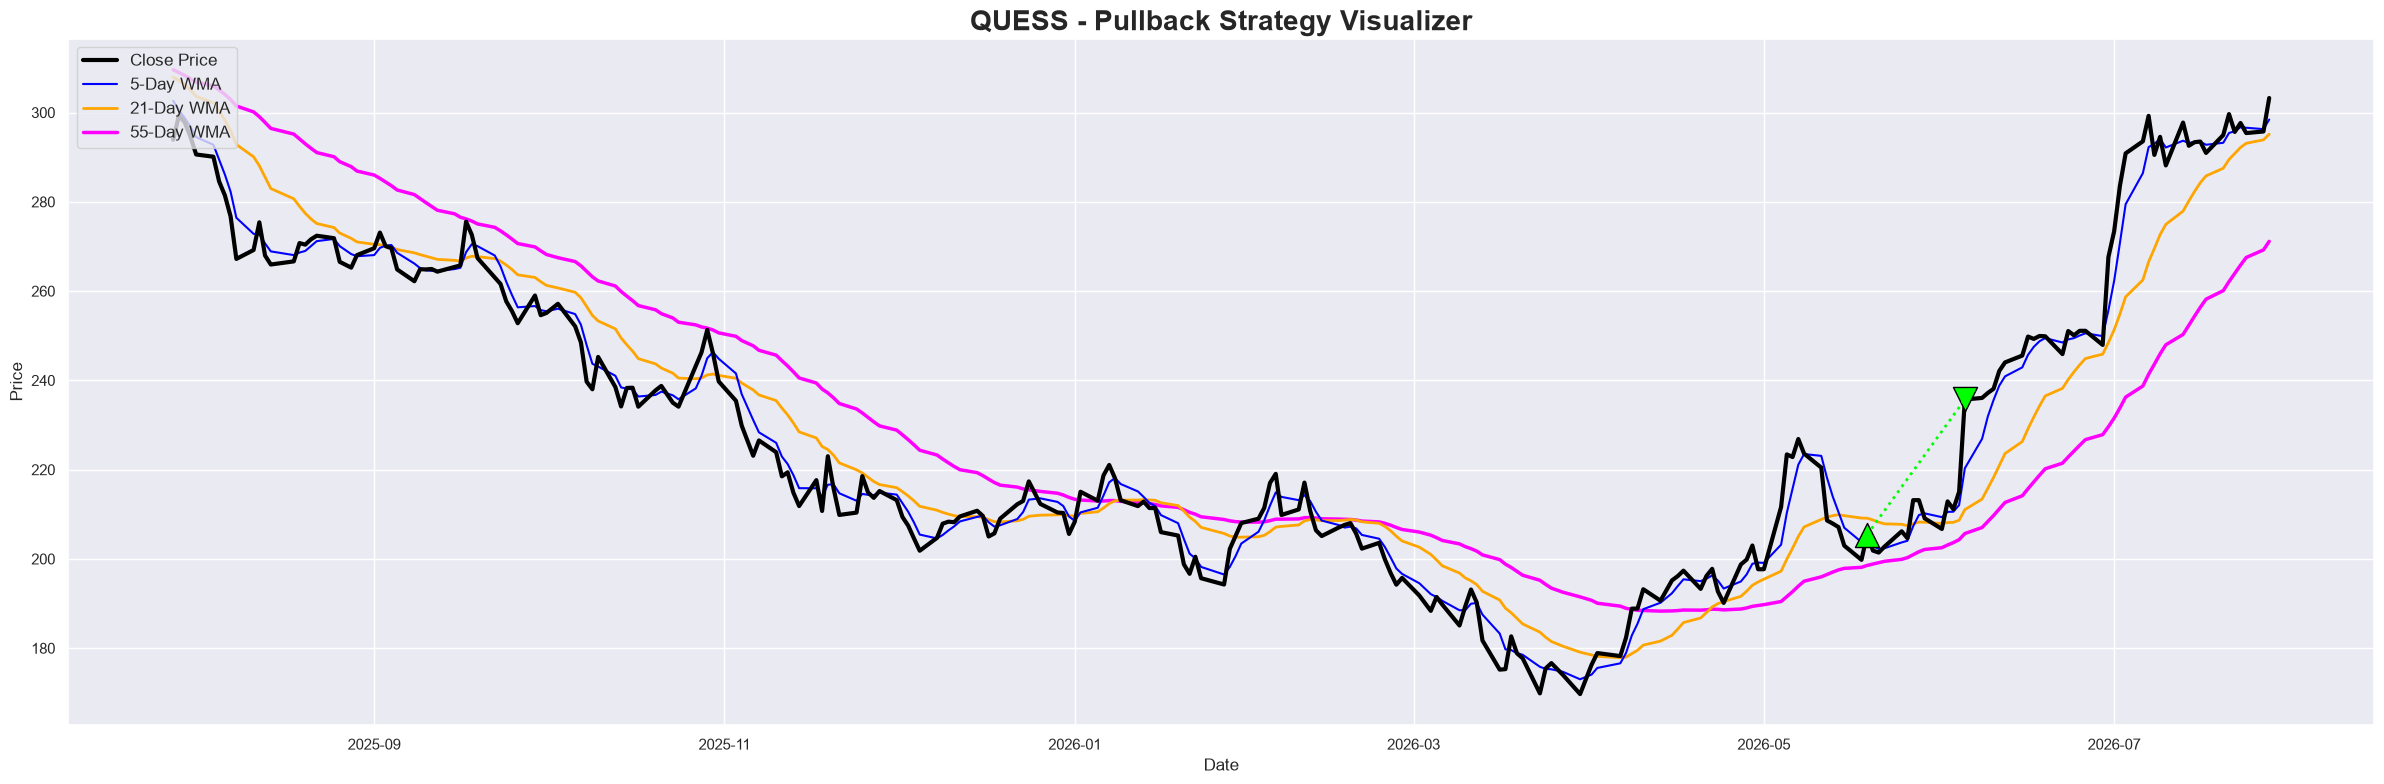

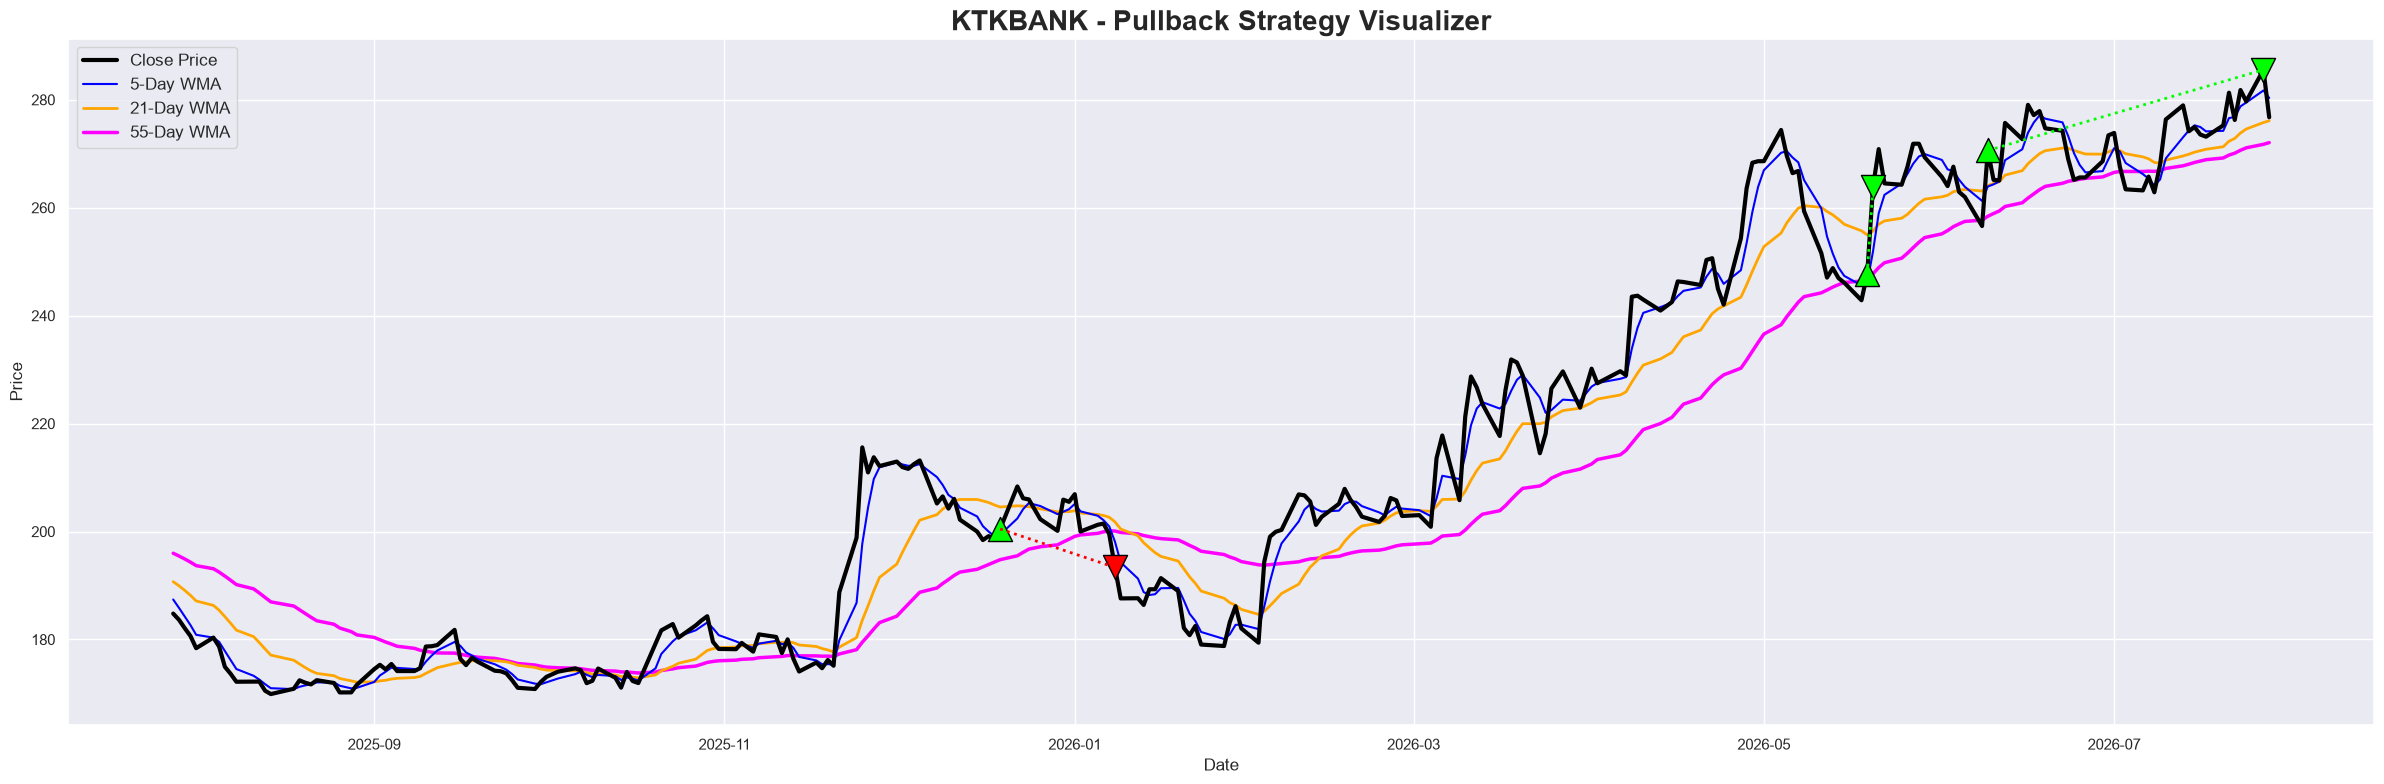

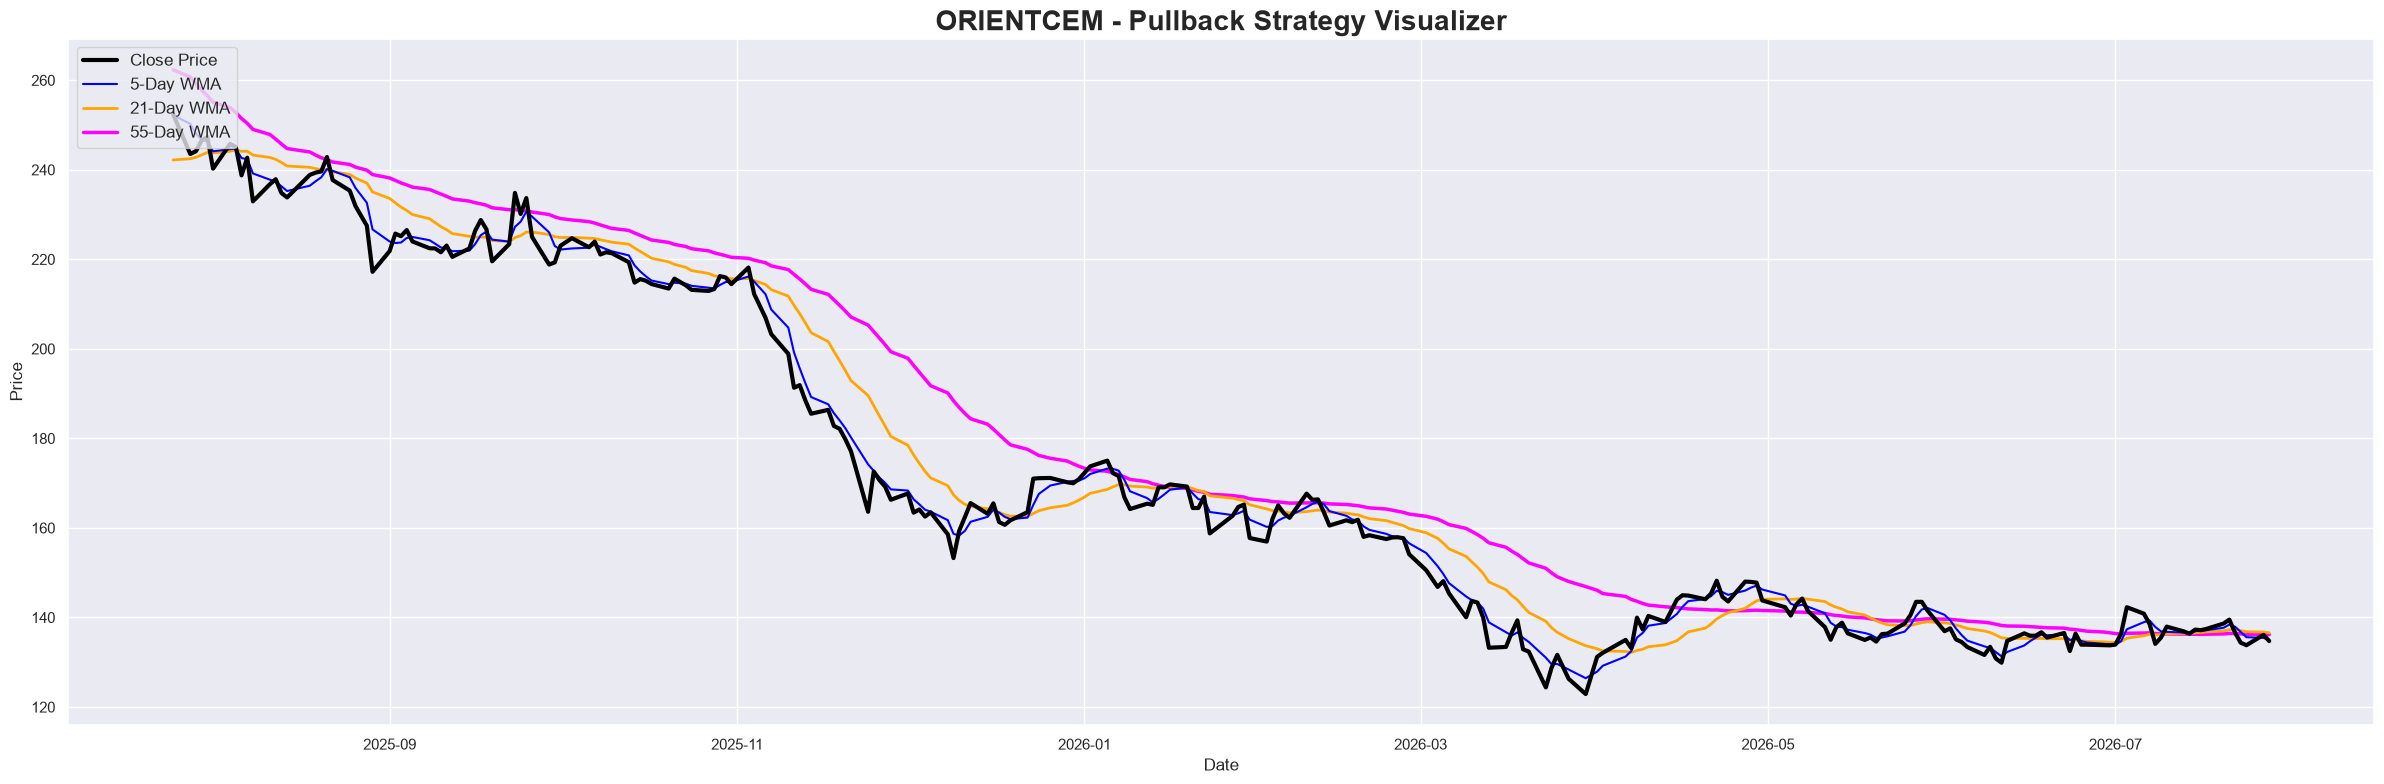

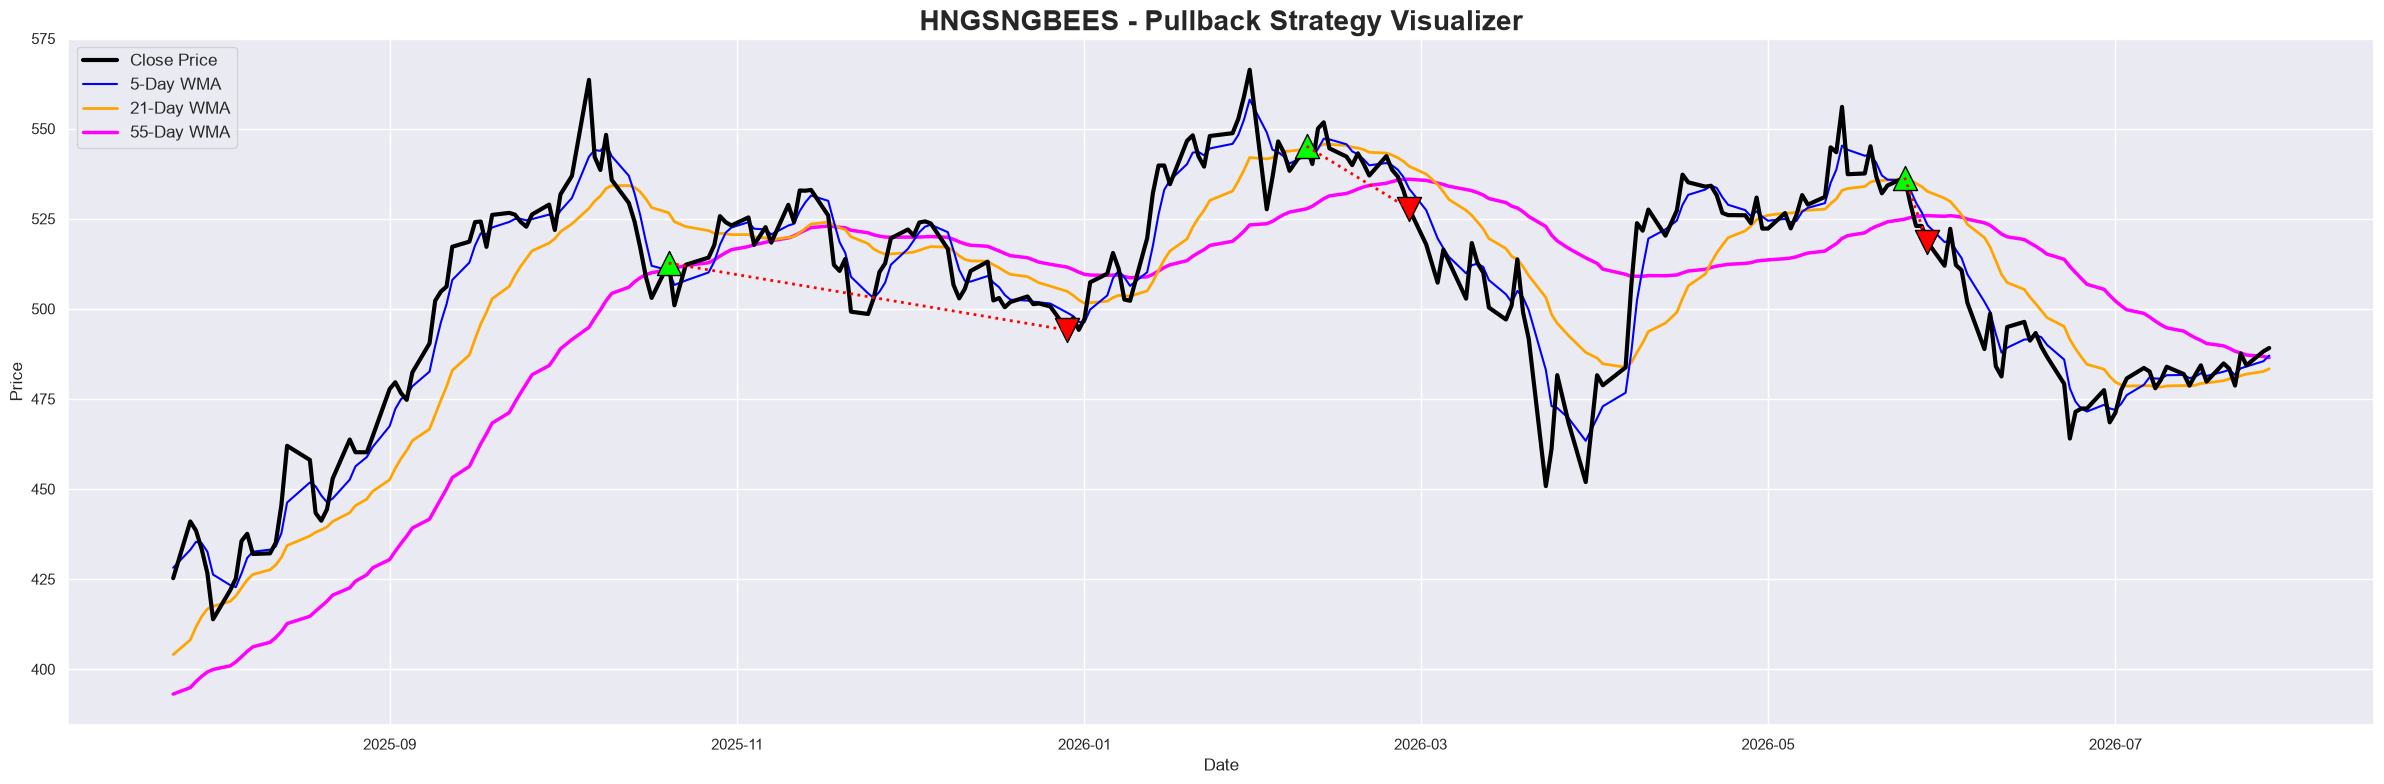

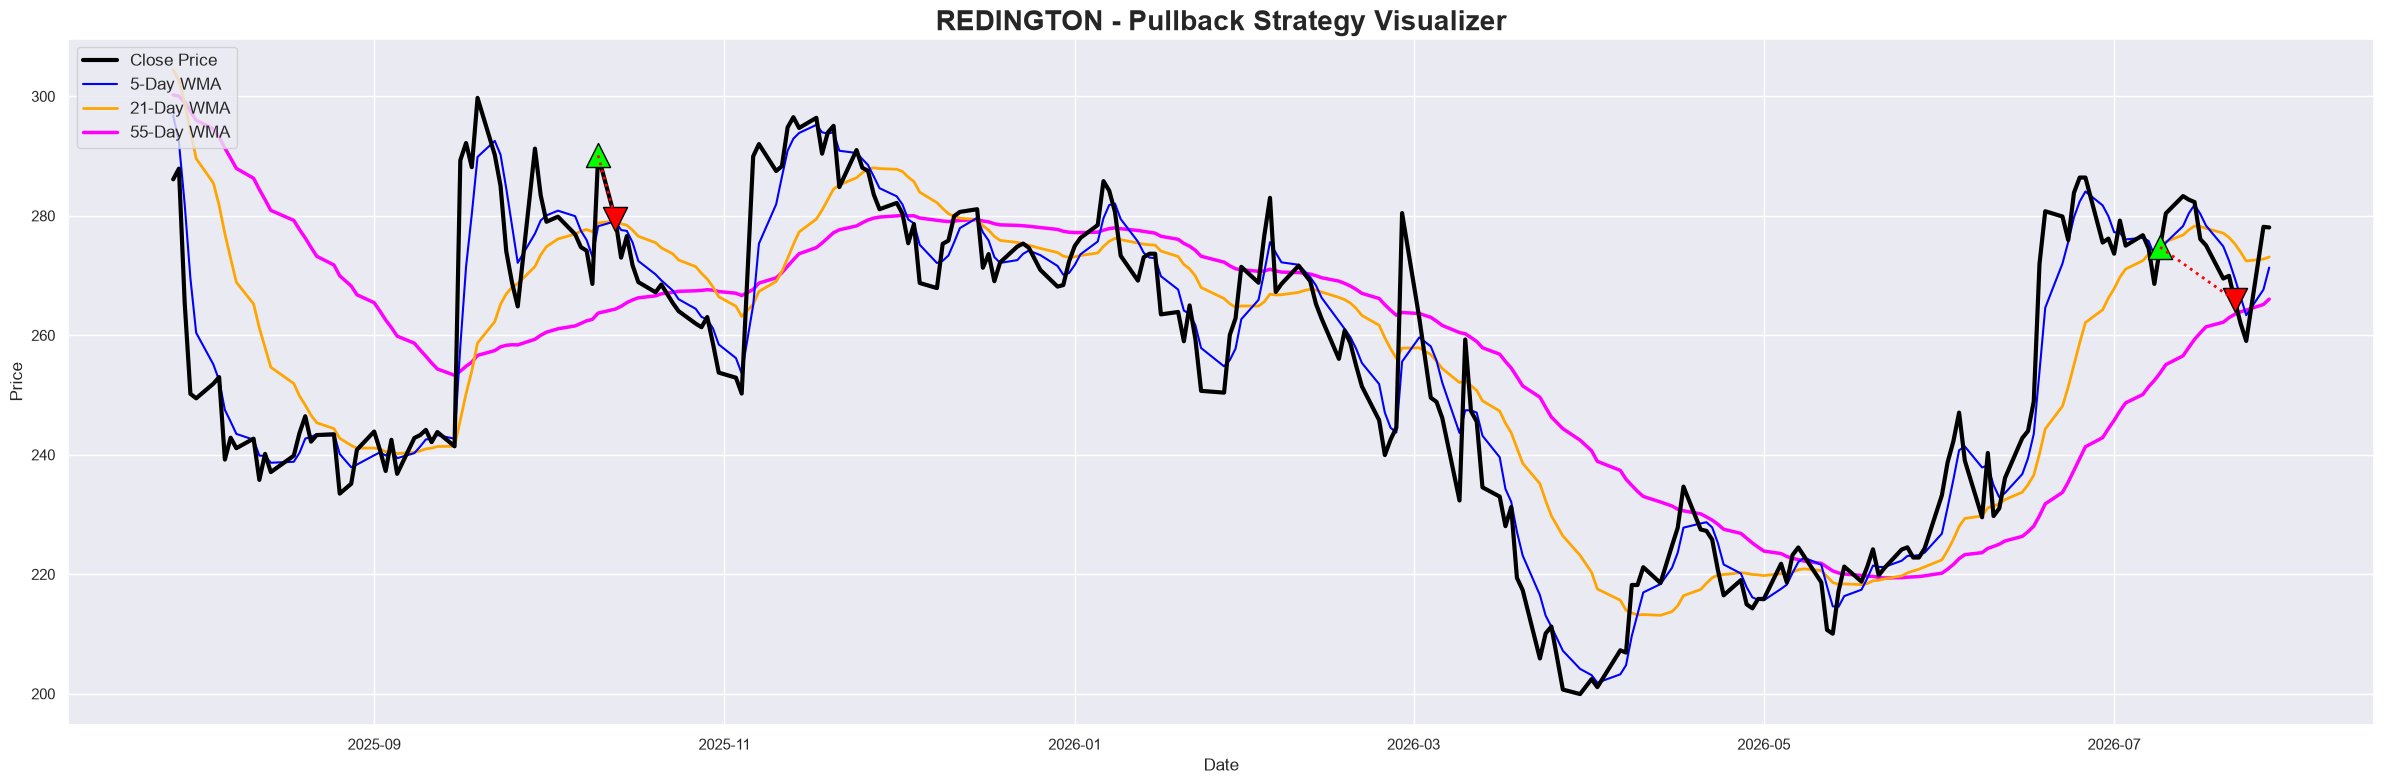

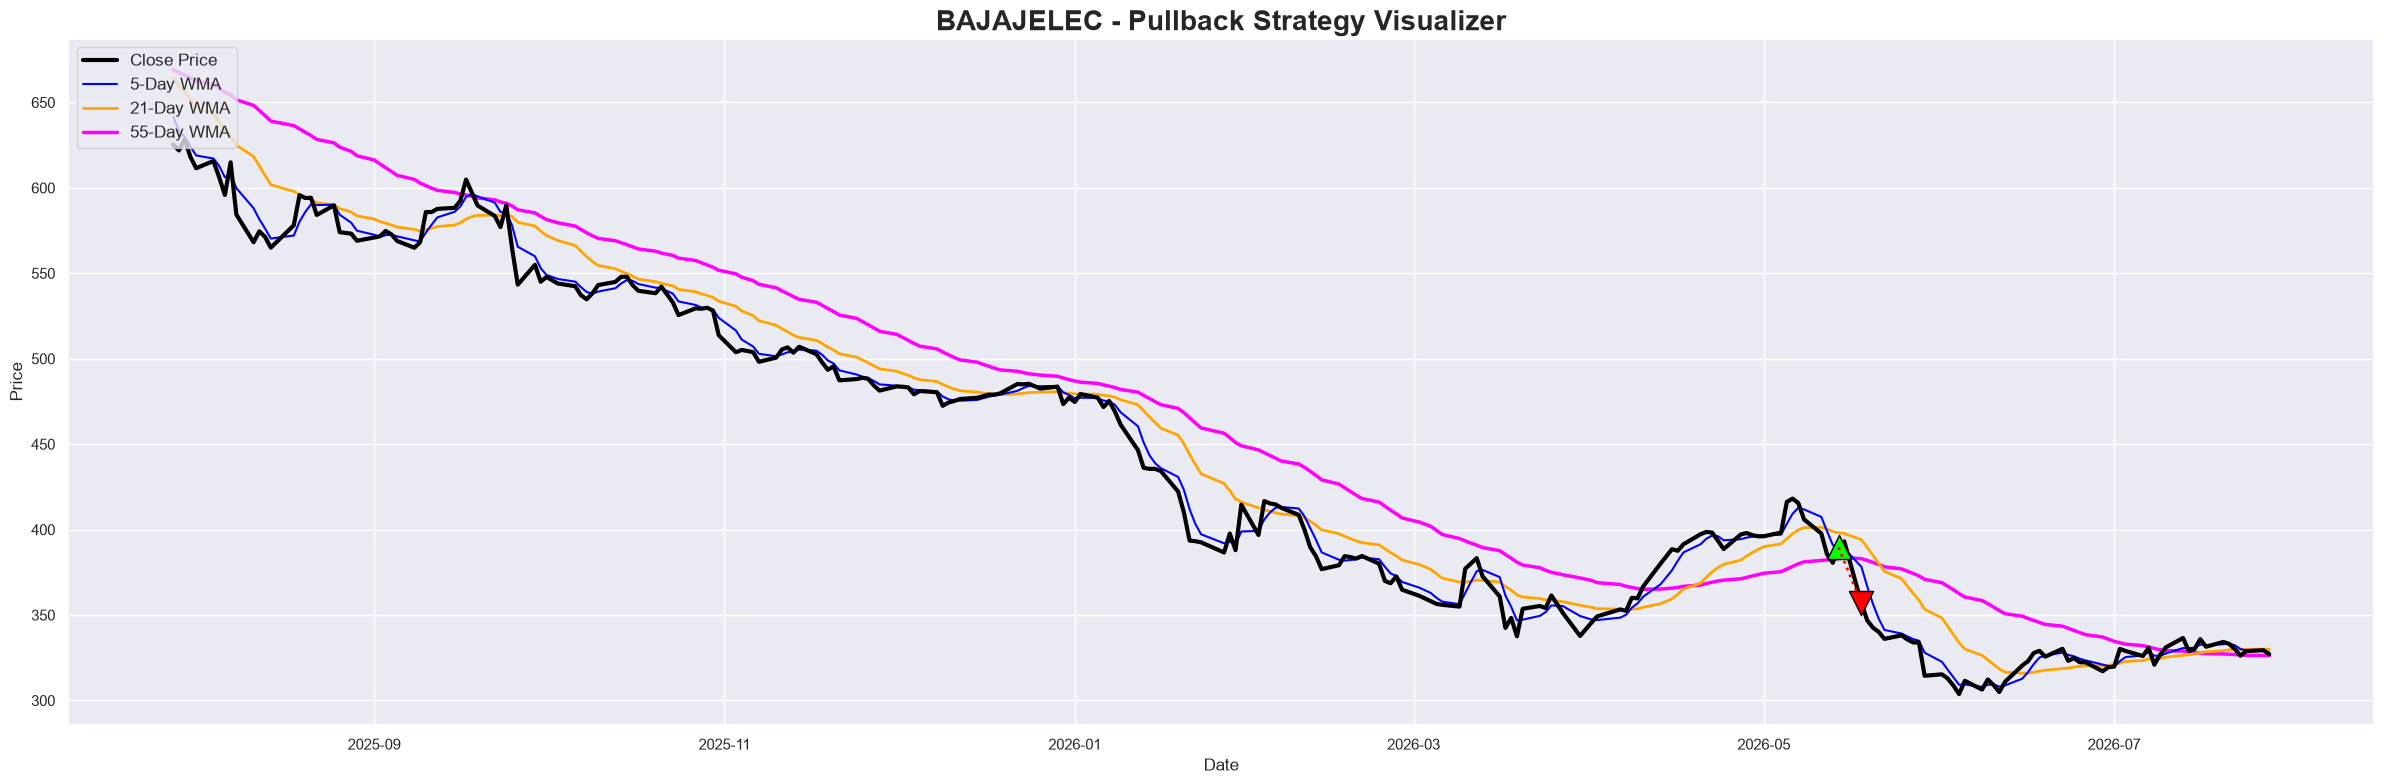

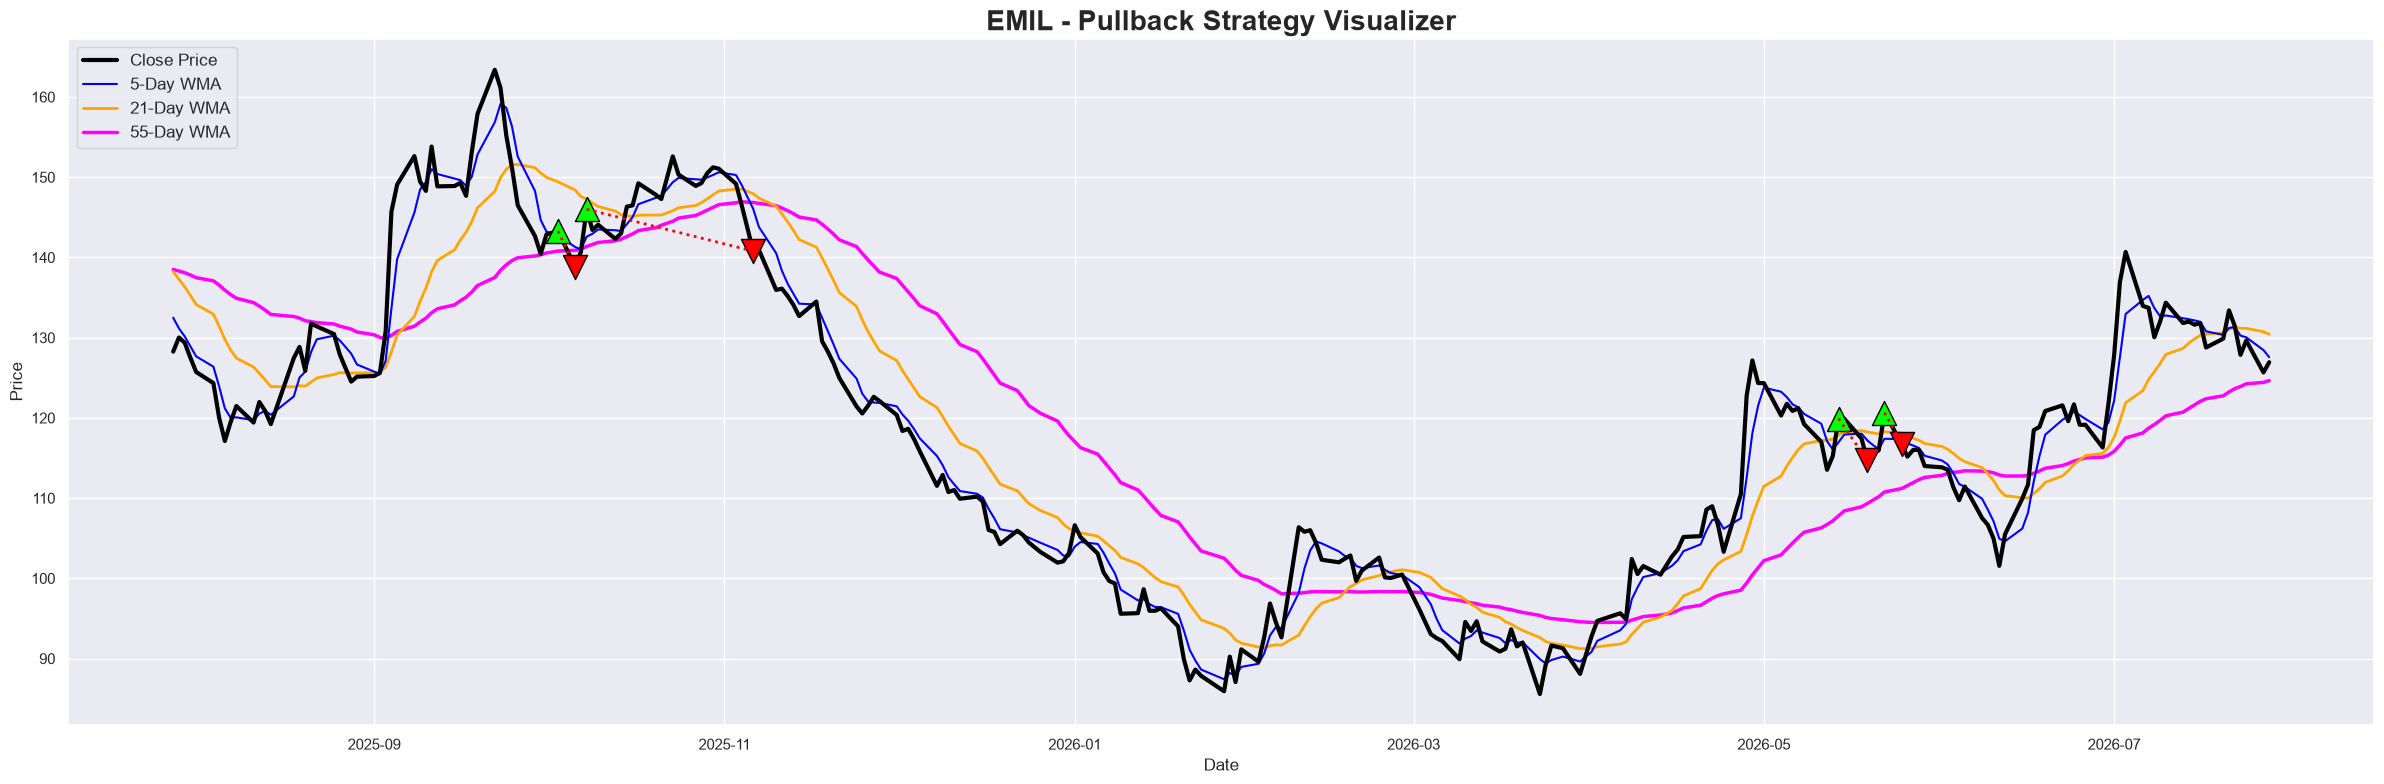

In [4]:
# 4. Visualizing the Trades
for symbol in symbols:
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    
    fig, ax = plt.subplots(figsize=(24, 8))
    
    # Plot Close Price (Solid Black)
    ax.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=3, zorder=5)
    
    # Plot WMAs
    ax.plot(df['Date'], df['WMA_5'], label='5-Day WMA', color='blue', linewidth=1.5, zorder=4)
    ax.plot(df['Date'], df['WMA_21'], label='21-Day WMA', color='orange', linewidth=2, zorder=3)
    ax.plot(df['Date'], df['WMA_55'], label='55-Day WMA', color='magenta', linewidth=2.5, zorder=2)
    
    # Plot Entries and Exits
    if len(trades_df) > 0:
        stock_trades = trades_df[trades_df['Symbol'] == symbol]
        for idx, trade in stock_trades.iterrows():
            ax.scatter(trade['Entry_Date'], trade['Entry_Price'], color='lime', marker='^', s=300, zorder=6, edgecolors='black')
            exit_color = 'lime' if trade['Profit_Pct'] > 0 else 'red'
            ax.scatter(trade['Exit_Date'], trade['Exit_Price'], color=exit_color, marker='v', s=300, zorder=6, edgecolors='black')
            ax.plot([trade['Entry_Date'], trade['Exit_Date']], [trade['Entry_Price'], trade['Exit_Price']], color=exit_color, linestyle=':', linewidth=2, zorder=6)
    
    ax.set_title(f"{symbol} - Pullback Strategy Visualizer", fontsize=20, fontweight='bold')
    ax.set_ylabel('Price')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=12)
    
    plt.tight_layout()
    plt.show()
